In [1]:
from pathlib import Path
import pandas as pd
import re

In [2]:
def NanPlot(df):
    # contar valores NaN en cada columna del dataframe
    nan_counts = df.isna().sum()
    nan_percent = df.isna().mean() * 100
    nan_percent.plot(kind="bar", title="Porcentaje de valores NaN por columna", ylabel="Porcentaje (%)", xlabel="Columnas", ylim=(0, 100), grid=True)

    print(df.head())
    print(df.shape)


In [3]:
CSV_DIR = Path("../data/raw/rumia")

csv_files = list(CSV_DIR.glob("*.csv"))

print("CSV encontrados:", len(csv_files))

for f in csv_files[:10]:
    print(f.name)

CSV encontrados: 8
group_1_ruminating_e7413f25-d0c4-44ea-b6f7-f176e7888d30_8666381325437215801.csv
group_102_ruminating_rumia.csv
group_20_ruminating.csv
group_106_ruminating_rumiando.csv
grupo 2 tiempo de rumia.csv
group_100_ruminating_rumia.csv
grupo 3 tiempo de rumia.csv
tiempo de rumia.csv


In [4]:
def LoadCsv(file_path):

    try:
        df = pd.read_csv(file_path)
    except:
        df = pd.read_csv(file_path, encoding="latin1")

    return df

In [5]:
dfs = []

for csv_file in csv_files:

    try:
        df = LoadCsv(csv_file)
        dfs.append(df)

    except Exception as e:
        print("Error en:", csv_file.name, e)

rumination_df = pd.concat(dfs, ignore_index=True)

print("Dataset combinado:", rumination_df.shape)

rumination_df.head()

Dataset combinado: (19110, 8)


,VID,EID,LID,Group,Last calving,Days in milk,Date,Ruminating
0,2110,NaN,NaN,1.0,12/01/2025,166.0,27/06/2025,NaN
1,2110,NaN,NaN,1.0,12/01/2025,167.0,28/06/2025,595.0
2,2110,NaN,NaN,1.0,12/01/2025,168.0,29/06/2025,569.0
3,2110,NaN,NaN,1.0,12/01/2025,169.0,30/06/2025,490.0
4,2110,NaN,NaN,1.0,12/01/2025,170.0,01/07/2025,581.0


    VID  EID  LID  Group Last calving  Days in milk        Date  Ruminating
0  2110  NaN  NaN    1.0   12/01/2025         166.0  27/06/2025         NaN
1  2110  NaN  NaN    1.0   12/01/2025         167.0  28/06/2025       595.0
2  2110  NaN  NaN    1.0   12/01/2025         168.0  29/06/2025       569.0
3  2110  NaN  NaN    1.0   12/01/2025         169.0  30/06/2025       490.0
4  2110  NaN  NaN    1.0   12/01/2025         170.0  01/07/2025       581.0
(19110, 8)


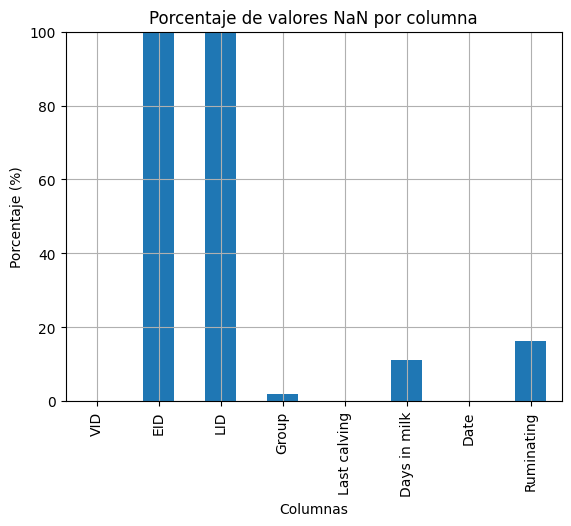

In [6]:
NanPlot(rumination_df)

In [7]:
rumination_df = rumination_df.drop(columns=["EID", "LID"])
rumination_df.head()

,VID,Group,Last calving,Days in milk,Date,Ruminating
0,2110,1.0,12/01/2025,166.0,27/06/2025,NaN
1,2110,1.0,12/01/2025,167.0,28/06/2025,595.0
2,2110,1.0,12/01/2025,168.0,29/06/2025,569.0
3,2110,1.0,12/01/2025,169.0,30/06/2025,490.0
4,2110,1.0,12/01/2025,170.0,01/07/2025,581.0


    VID  Group Last calving  Days in milk        Date  Ruminating
0  2110    1.0   12/01/2025         166.0  27/06/2025         NaN
1  2110    1.0   12/01/2025         167.0  28/06/2025       595.0
2  2110    1.0   12/01/2025         168.0  29/06/2025       569.0
3  2110    1.0   12/01/2025         169.0  30/06/2025       490.0
4  2110    1.0   12/01/2025         170.0  01/07/2025       581.0
(19110, 6)


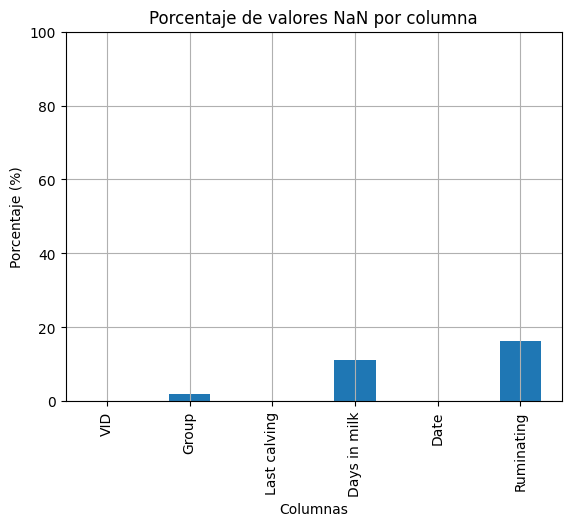

In [8]:
NanPlot(rumination_df)

In [9]:
rumination_df = rumination_df.rename(columns={
    "VID": "cow_id",
    "Last calving": "last_calving",
    "Days in milk": "days_in_milk",
    "Ruminating": "ruminating_minutes",
    "Date": "date",
    "Group": "group"
})

   cow_id  group last_calving  days_in_milk        date  ruminating_minutes
0    2110    1.0   12/01/2025         166.0  27/06/2025                 NaN
1    2110    1.0   12/01/2025         167.0  28/06/2025               595.0
2    2110    1.0   12/01/2025         168.0  29/06/2025               569.0
3    2110    1.0   12/01/2025         169.0  30/06/2025               490.0
4    2110    1.0   12/01/2025         170.0  01/07/2025               581.0
(19110, 6)


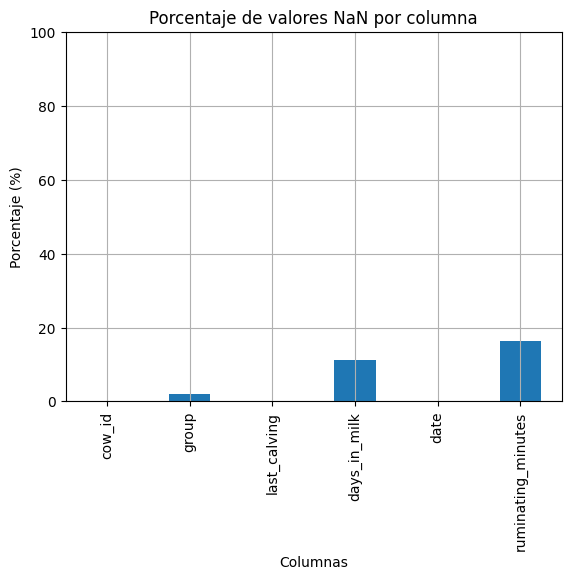

In [10]:
NanPlot(rumination_df)

   cow_id  group last_calving  days_in_milk        date  ruminating_minutes
1    2110      1   12/01/2025           167  28/06/2025                 595
2    2110      1   12/01/2025           168  29/06/2025                 569
3    2110      1   12/01/2025           169  30/06/2025                 490
4    2110      1   12/01/2025           170  01/07/2025                 581
5    2110      1   12/01/2025           171  02/07/2025                 459
(14654, 6)


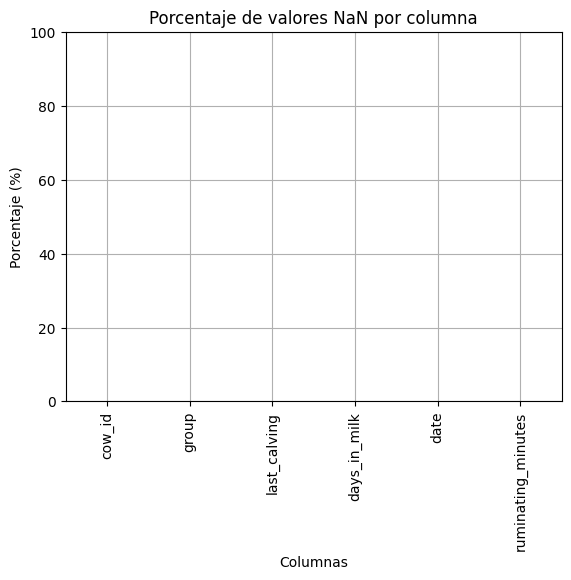

In [11]:
cols = ["days_in_milk", "ruminating_minutes", "group"]

rumination_df = rumination_df.dropna(subset=cols)
rumination_df[cols] = rumination_df[cols].astype(int)
NanPlot(rumination_df)

In [12]:
rumination_df["date"] = pd.to_datetime(
    rumination_df["date"],
    dayfirst=True,
    errors="coerce"
)
rumination_df["last_calving"] = pd.to_datetime(
    rumination_df["last_calving"],
    dayfirst=True,
    errors="coerce"
)
rumination_df.head()

,cow_id,group,last_calving,days_in_milk,date,ruminating_minutes
1,2110,1,2025-01-12,167,2025-06-28,595
2,2110,1,2025-01-12,168,2025-06-29,569
3,2110,1,2025-01-12,169,2025-06-30,490
4,2110,1,2025-01-12,170,2025-07-01,581
5,2110,1,2025-01-12,171,2025-07-02,459


In [13]:
rumination_df.info()

<class 'pandas.DataFrame'>
Index: 14654 entries, 1 to 19108
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cow_id              14654 non-null  int64         
 1   group               14654 non-null  int64         
 2   last_calving        14654 non-null  datetime64[us]
 3   days_in_milk        14654 non-null  int64         
 4   date                14654 non-null  datetime64[us]
 5   ruminating_minutes  14654 non-null  int64         
dtypes: datetime64[us](2), int64(4)
memory usage: 801.4 KB


In [14]:
OUTPUT_PATH = Path("../data/interim/rumination.parquet")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

rumination_df.to_parquet(OUTPUT_PATH)

print("Dataset guardado en:", OUTPUT_PATH)

Dataset guardado en: ../data/interim/rumination.parquet
